In [1]:
!git clone https://github.com/mareksubocz/QRBM
%cd QRBM


Cloning into 'QRBM'...
remote: Enumerating objects: 238, done.
remote: Counting objects: 100% (238/238), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 238 (delta 103), reused 175 (delta 57), pack-reused 0
Receiving objects: 100% (238/238), 23.11 MiB | 18.87 MiB/s, done.
Resolving deltas: 100% (103/103), done.
/content/QRBM


In [2]:
import numpy as np
import timeit
import matplotlib.pyplot as plt
from tqdm import tqdm_notebook as tqdm
!pip install dwave-system
!pip install pyqubo
from qrbm.MSQRBM import MSQRBM
from qrbm.classicalRBM import classicalRBM


import matplotlib.pyplot as plt
%matplotlib inline   
plt.rcParams['image.cmap'] = 'gray'

import pandas as pd

from skimage import data, color
from skimage.transform import rescale, resize, downscale_local_mean
from skimage import img_as_bool

import cv2 as cv

import random

     |████████████████████████████████| 87 kB 4.1 MB/s 
     |████████████████████████████████| 697 kB 28.1 MB/s 
     |████████████████████████████████| 3.3 MB 38.7 MB/s 
     |████████████████████████████████| 88 kB 5.5 MB/s 
     |████████████████████████████████| 782 kB 38.3 MB/s 
     |████████████████████████████████| 103 kB 78.2 MB/s 
     |████████████████████████████████| 13.1 MB 64 kB/s 
     |████████████████████████████████| 10.1 MB 23.8 MB/s 
     |████████████████████████████████| 887 kB 7.6 MB/s 
     |████████████████████████████████| 397 kB 52.1 MB/s 


In [3]:
image_height = 28
image_width = 28

# images will be flattened
len_x = image_height * image_width
len_y = 0

digits = [0, 1]
THRESHOLD = 100
n_hidden = 30
qpu = False
epochs = 1000
lr = 0.1

In [4]:
from google.colab import drive
drive.mount('/content/gdrive')
import os
os.environ['KAGGLE_CONFIG_DIR'] = "/content/gdrive/My Drive/Kaggle"
%cd /content/gdrive/My Drive/Kaggle
!kaggle datasets download -d oddrationale/mnist-in-csv



Mounted at /content/gdrive
/content/gdrive/My Drive/Kaggle
 66% 10.0M/15.2M [00:00<00:00, 11.6MB/s]
100% 15.2M/15.2M [00:00<00:00, 31.0MB/s]


In [5]:
!ls

bollywood_celeb_faces_0  cifar-10-python.tar.gz  mnist_test.csv
bollywood_celeb_faces_1  cifar10-python.zip	 mnist_train.csv
bollywood_celeb_faces2	 kaggle.json		 question_one_dataset
cifar-10-batches-py	 mnist-in-csv.zip	 question_three_dataset


In [6]:
# !unzip \*.zip  && rm mnist-in-csv.zip


mnist_dataset = pd.read_csv('mnist_train.csv')
mnist_test = pd.read_csv('mnist_test.csv')

In [7]:
!ls

bollywood_celeb_faces_0  cifar-10-python.tar.gz  mnist_test.csv
bollywood_celeb_faces_1  cifar10-python.zip	 mnist_train.csv
bollywood_celeb_faces2	 kaggle.json		 question_one_dataset
cifar-10-batches-py	 mnist-in-csv.zip	 question_three_dataset


In [8]:
X_train = mnist_dataset.values[:,1:]
X_train2 = mnist_dataset.values[:,:]

X_test = mnist_test.values[:,1:]
X_test2 = mnist_test.values[:,:]

# print(mnist_dataset.values[:,0])
X_train3 = []
X_test3 = []

for digit in digits:
    X_train3.append(mnist_dataset.values[np.where(mnist_dataset.values[:,0] == digit), 1:][0])
    X_test3.append(mnist_test.values[np.where(mnist_test.values[:,0] == digit), 1:][0])
# X_train3 = mnist_dataset.values[np.where(mnist_dataset.values[:,0] == 0), 1:]

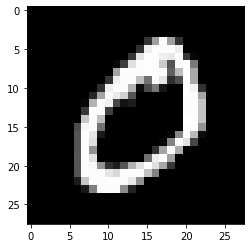

In [9]:
imgs = []
imgs_test = []
for digit_index in range(len(digits)):
    imgs.append(np.resize(X_train3[digit_index], (len(X_train3[digit_index]), 28, 28)) / 255)
    imgs_test.append(np.resize(X_test3[digit_index], (len(X_test3[digit_index]), 28, 28)) / 255)
    
plt.imshow(imgs[0][0])
plt.show()

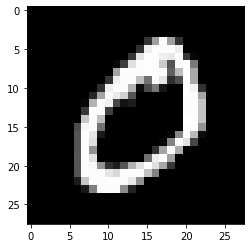

In [10]:
images_resized = []
images_resized_test = []
for digit_index in range(len(digits)):
    images_resized.append([resize(img, (image_width, image_height), anti_aliasing=True) for img in imgs[digit_index]])
    images_resized_test.append([resize(img, (image_width, image_height), anti_aliasing=True) for img in imgs_test[digit_index]])

    # images_resized = [resize(img, (image_width, image_height), anti_aliasing=True) for img in imgs]

plt.imshow(images_resized[0][0])
plt.show()

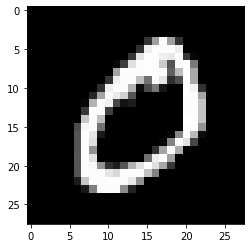

In [11]:
images_normalized = []
images_normalized_test = []

for digit_index in range(len(digits)):
    images_normalized.append([cv.normalize(image_resized, image_resized, 0, 255, cv.NORM_MINMAX) for image_resized in images_resized[digit_index]])
    images_normalized_test.append([cv.normalize(image_resized, image_resized, 0, 255, cv.NORM_MINMAX) for image_resized in images_resized_test[digit_index]])

    # images_normalized = [cv.normalize(image_resized, image_resized, 0, 255, cv.NORM_MINMAX) for image_resized in images_resized]

plt.imshow(images_normalized[0][0])
plt.show()

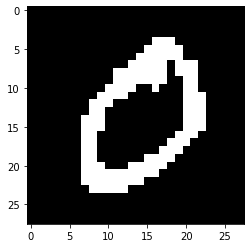

In [12]:
data = []
data_test = []
for digit_index in range(len(digits)):
    data.append([np.where(image_resized > THRESHOLD, 1, 0) for image_resized in images_resized[digit_index]])
    data_test.append([np.where(image_resized > THRESHOLD, 1, 0) for image_resized in images_resized_test[digit_index]])
    
# data = [np.where(image_resized > THRESHOLD, 1, 0) for image_resized in images_resized]

plt.imshow(data[0][0])
plt.show()

In [13]:
input_data = []
input_data_test = []
for digit_index in range(len(digits)):
    input_data.append([x.flatten().tolist() for x in data[digit_index]])
    input_data_test.append([x.flatten().tolist() for x in data_test[digit_index]])
    
print(input_data[0][0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 

In [14]:

result_picture_tab = []
for digit_index in range(len(digits)):
    result_picture_tab.append(np.mean(input_data_test[digit_index], axis = 0))

In [15]:
for digit in digits:
    flat_input_data = [item for sublist in input_data for item in sublist]
    flat_input_data_test = [item for sublist in input_data_test for item in sublist]

random.shuffle(flat_input_data)
random.shuffle(flat_input_data_test)

In [16]:
bm = MSQRBM(n_visible=len_x, n_hidden=n_hidden, qpu=qpu)
bm.image_height = image_height
bm.tqdm = tqdm
bm.result_picture_tab = result_picture_tab

  0%|          | 0/1000 [00:00<?, ?it/s]

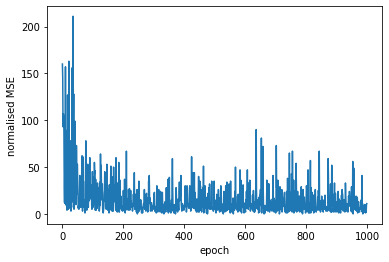

In [17]:
bm.train(flat_input_data, len_x, len_y, epochs = epochs, lr = lr, lr_decay = 0.1)


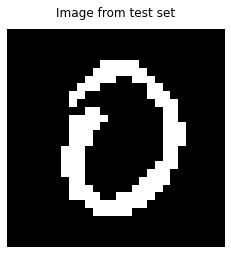

evaluation:  58.642350062473966


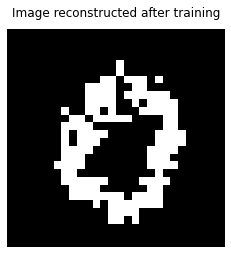

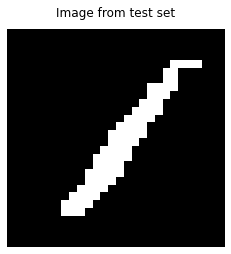

evaluation:  45.50187894195501


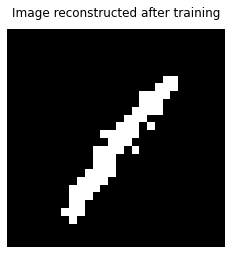

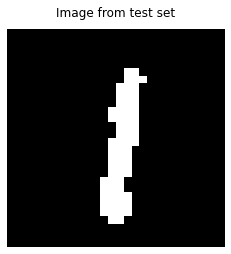

evaluation:  19.724786430941798


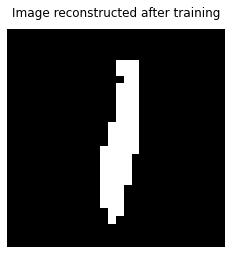

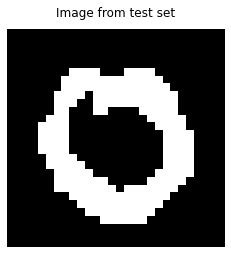

evaluation:  76.51990108288214


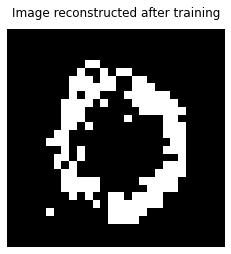

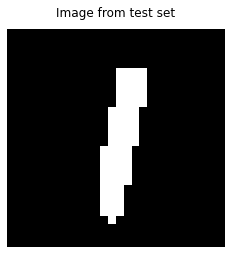

evaluation:  19.724786430941798


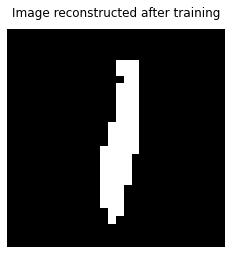

In [18]:
for test in range(5):
    flat_input_data_test_img = np.reshape(flat_input_data_test[test], (image_width, image_height))
    plt.figure()
    plt.axis('off')
    plt.title("Image from test set", y=1.03)
    plt.imshow(flat_input_data_test_img)
    plt.show()
    
    generated_pic = bm.generate(test_img = flat_input_data_test[test])
    evaluation = bm.evaluate(generated_pic, flat_input_data_test[test])
    print("evaluation: ", evaluation)
#     print(generated_pic)
    plt.figure()
    plt.axis('off')
    plt.title("Image reconstructed after training", y=1.03)
    plt.imshow(np.array(generated_pic).reshape(image_height, -1))